<a href="https://colab.research.google.com/github/Harish2859/Learning-Supervised-Classification-Titanic/blob/main/TITANIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Titanic-Dataset.csv')
print(df.head())

In [ ]:
df_cleaned = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df_cleaned['Age'] = df_cleaned['Age'].fillna(df_cleaned['Age'].median())
df_cleaned['Embarked'] = df_cleaned['Embarked'].fillna(df_cleaned['Embarked'].mode()[0])
df_cleaned['Sex'] = df_cleaned['Sex'].map({'female': 0, 'male': 1})
df_final = pd.get_dummies(df_cleaned, columns=['Embarked'], drop_first=True)
print(df_final.head())

In [14]:
X = df_final.drop('Survived', axis=1)
y = df_final['Survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

In [18]:
model = LogisticRegression(max_iter=1000)

In [19]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
predictions = model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 81.01%


In [23]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

      Feature  Importance
5        Fare    0.002570
2         Age   -0.030592
4       Parch   -0.108025
6  Embarked_Q   -0.112181
3       SibSp   -0.294975
7  Embarked_S   -0.401270
0      Pclass   -0.938550
1         Sex   -2.590612


Decision Tree Accuracy: 79.89%


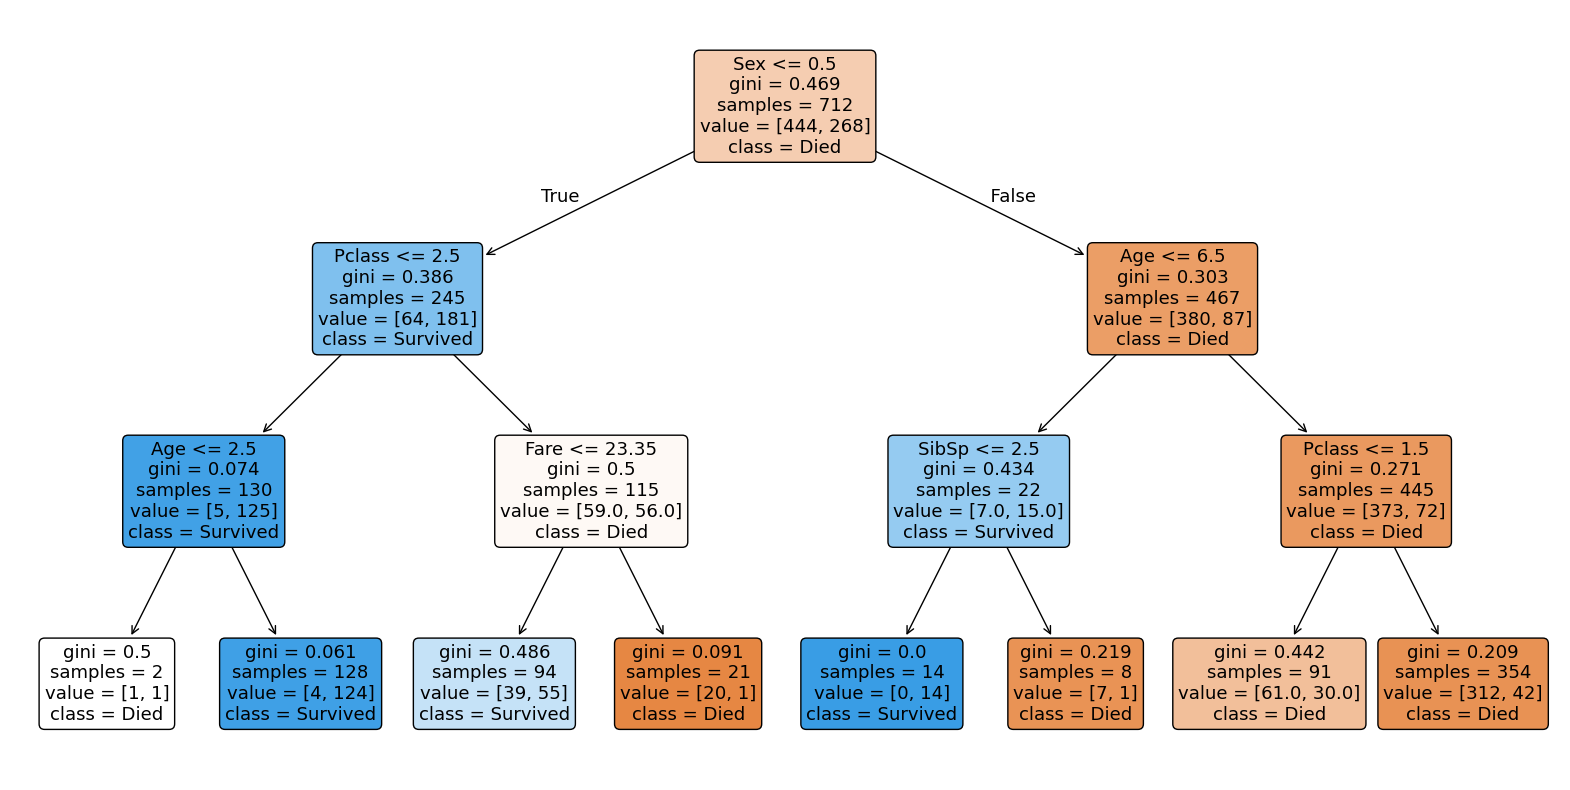

In [31]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_preds)
print(f"Decision Tree Accuracy: {tree_acc * 100:.2f}%")
plt.figure(figsize=(20,10))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True)
plt.show()

In [37]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy, tree_acc, rf_acc]
})

print(results)

Random Forest Accuracy: 81.56%
                 Model  Accuracy
0  Logistic Regression  0.810056
1        Decision Tree  0.798883
2        Random Forest  0.815642


In [40]:
print(list(X_train.columns))

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


In [41]:
my_data = np.array([[1, 0, 25, 1, 0, 100.0, 0, 1]])
prediction = rf_model.predict(my_data)
probability = rf_model.predict_proba(my_data)
if prediction[0] == 1:
    print(f"You Survived! 🎉 (Chance: {probability[0][1]*100:.2f}%)")
else:
    print(f"You did not survive. 💀 (Death Chance: {probability[0][0]*100:.2f}%)")

You Survived! 🎉 (Chance: 90.63%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


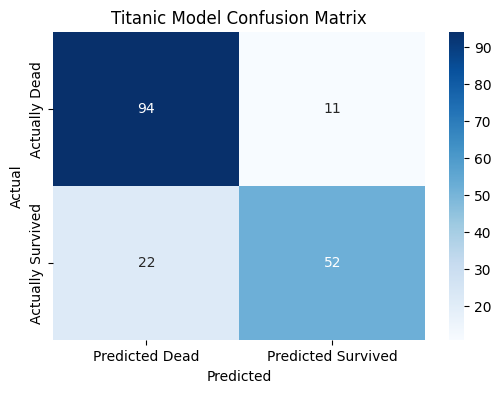

In [44]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dead', 'Predicted Survived'],
            yticklabels=['Actually Dead', 'Actually Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Titanic Model Confusion Matrix')
plt.show()